<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
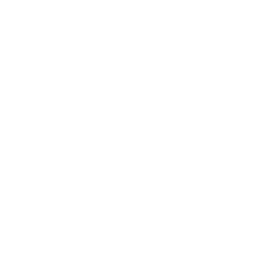
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clustering dell'Efficienza Energetica degli Edifici</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energia / Analisi della Sostenibilità &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

Questo esempio pratico raggruppa un portafoglio di edifici commerciali secondo cinque metriche di efficienza energetica — Intensità di Utilizzo Energetico (EUI), rapporto di efficienza HVAC, resistenza termica dell'involucro, densità di potenza dell'illuminazione e percentuale di compensazione rinnovabile — per far emergere livelli di prestazione distinti utili a mirare gli incentivi delle utility. L'analisi usa **PROC FASTCLUS** con `REPLACE=FULL` (sostituzione completa dei semi) e confronta le soluzioni k=3, 4, 5 e 6 su R-quadro complessivo, statistica pseudo-F e dimensione minima del cluster. La soluzione k=4 viene poi profilata in dettaglio e ogni cluster è mappato su un livello di efficienza attuabile. Poiché questo ambiente funziona senza licenza, la dimostrazione è limitata a un campione di 100 edifici; lo stesso programma si estende senza modifiche a un intero portafoglio.

## Fonti dei Dati

| Fonte | Descrizione | Record |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Metriche annuali di efficienza energetica per edificio (sintetiche) | 100 |


---

In [1]:
DATI work.building_metrics;
    CHIAMARE streaminit(42);
    VETTORE btypes[5] $15 _temporary_ ('UFFICIO' 'NEGOZIO' 'MAGAZZINO' 'OSPEDALE' 'SCUOLA');
    VETTORE regions[4] $12 _temporary_ ('NORDEST' 'SUDEST' 'MIDWEST' 'OVEST');
    ETICHETTA building_id="ID Edificio" building_type="Tipo di Edificio" climate_region="Regione Climatica"
          eui="Intensità di Utilizzo Energetico" hvac_efficiency="Efficienza HVAC"
          envelope_r_value="Resistenza Termica Involucro" lighting_wpf="Densità di Potenza Illuminazione"
          renewable_pct="Percentuale Rinnovabile" building_age="Età dell'Edificio"
          floor_area_ksf="Superficie (migliaia di sqft)";
    FARE building_id = 1 FINO_A 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        building_type = btypes[type_idx];
        reg_idx = int(rand('uniform') * 4) + 1;
        climate_region = regions[reg_idx];

        /* Energy Use Intensity (kBtu/sqft/yr) */
        eui = round(rand('normal', 85, 35), 0.1);
        SE_COND eui < 15 ALLORA eui = 15;
        SE_COND eui > 250 ALLORA eui = 250;

        /* HVAC efficiency ratio (COP equivalent) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        SE_COND hvac_efficiency < 1.0 ALLORA hvac_efficiency = 1.0;
        SE_COND hvac_efficiency > 6.0 ALLORA hvac_efficiency = 6.0;

        /* Envelope thermal resistance (R-value) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        SE_COND envelope_r_value < 5 ALLORA envelope_r_value = 5;
        SE_COND envelope_r_value > 40 ALLORA envelope_r_value = 40;

        /* Lighting power density (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        SE_COND lighting_wpf < 0.3 ALLORA lighting_wpf = 0.3;
        SE_COND lighting_wpf > 2.5 ALLORA lighting_wpf = 2.5;

        /* Renewable energy offset percentage */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        SE_COND renewable_pct > 80 ALLORA renewable_pct = 80;

        /* Building age in years */
        building_age = int(rand('uniform') * 80) + 1;

        /* Floor area (thousands of sqft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        SE_COND floor_area_ksf > 500 ALLORA floor_area_ksf = 500;

        USCITA;
    FINE;
    RIMUOVERE type_idx reg_idx;
ESEGUIRE;


NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.65 seconds
  cpu   1.65 seconds


---

In [2]:
PROCEDURA MEDIE DATI=work.building_metrics n mean std;
    CLASSE building_type;
    VARIABILE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITOLO "Metriche Energetiche per Tipo di Edificio";
ESEGUIRE;

                                       Metriche Energetiche per Tipo di Edificio                                        

                                                  The MEANS Procedure

                               Analysis Variable : eui Intensità di Utilizzo Energetico

        Tipo di Edificio          N Obs           Mean        Std Dev
        -------------------------------------------------------------
        MAGAZZINO                    20     90.8900000     33.5993249
        NEGOZIO                      16     79.7312500     42.6818106
        OSPEDALE                     25     87.9040000     35.2632892
        SCUOLA                       19     89.7000000     39.0498542
        UFFICIO                      20     73.0550000     40.3950163
        -------------------------------------------------------------

                                  Analysis Variable : hvac_efficiency Efficienza HVAC

        Tipo di Edificio          N Obs           Mean        Std Dev



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                       Metriche Energetiche per Tipo di Edificio                                        




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


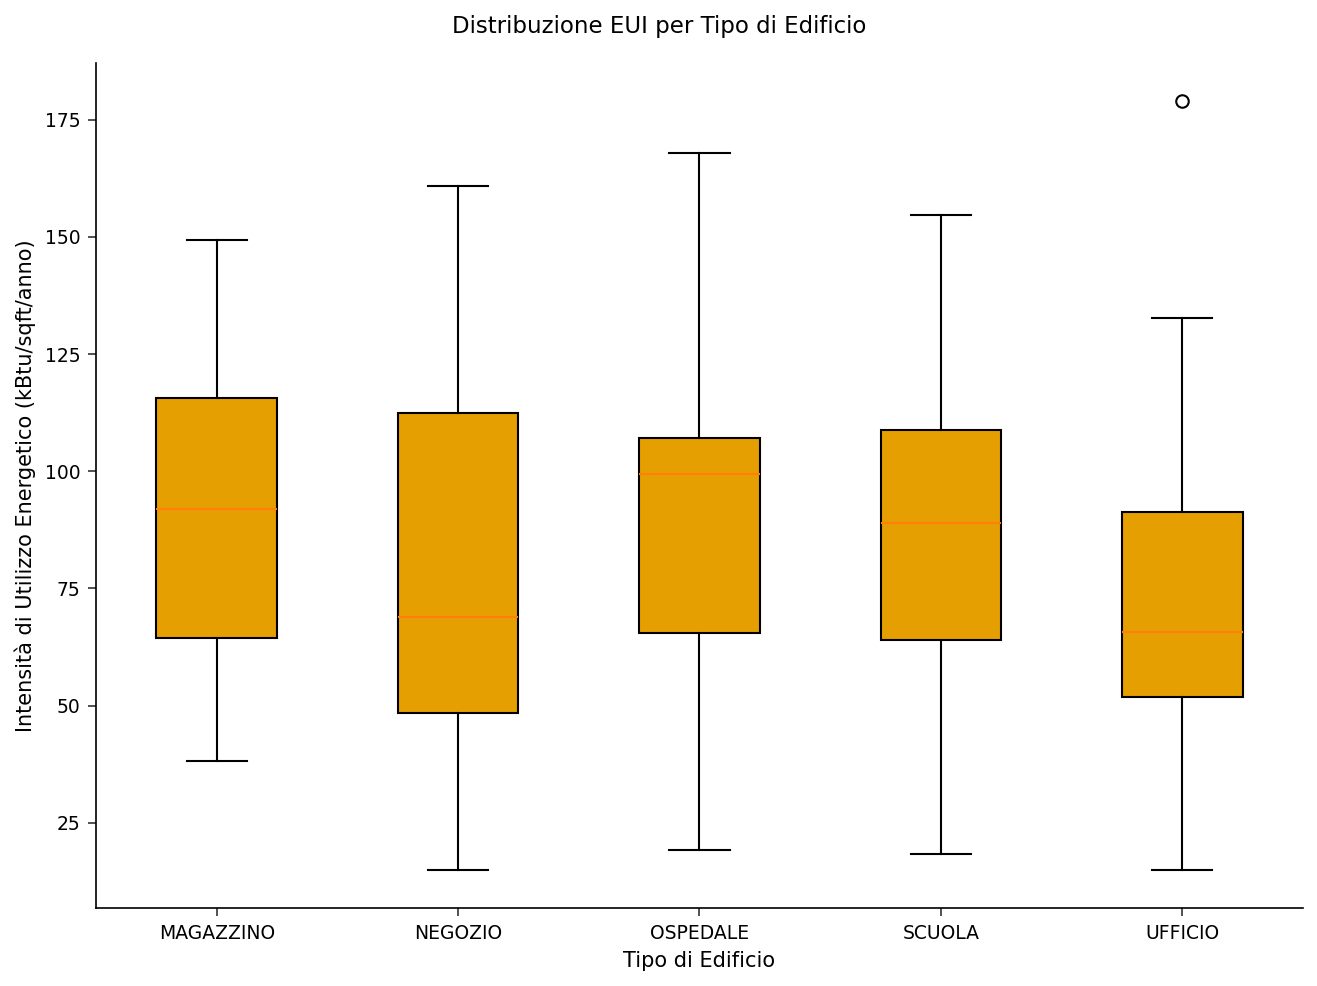

In [3]:
PROCEDURA SGPLOT DATI=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS ETICHETTA='Tipo di Edificio';
    YAXIS ETICHETTA='Intensità di Utilizzo Energetico (kBtu/sqft/anno)';
    TITOLO 'Distribuzione EUI per Tipo di Edificio';
ESEGUIRE;

---

In [4]:
PROCEDURA STANDARD DATI=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    VARIABILE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
ESEGUIRE;


NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
PROCEDURA FASTCLUS DATI=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    VARIABILE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITOLO "Clustering Efficienza Edifici: k=3 REPLACE=FULL";
ESEGUIRE;

                                       Metriche Energetiche per Tipo di Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
PROCEDURA FASTCLUS DATI=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    VARIABILE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITOLO "Clustering Efficienza Edifici: k=4 REPLACE=FULL";
ESEGUIRE;

                                       Metriche Energetiche per Tipo di Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
PROCEDURA FASTCLUS DATI=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    VARIABILE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITOLO "Clustering Efficienza Edifici: k=5 REPLACE=FULL";
ESEGUIRE;

                                       Metriche Energetiche per Tipo di Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
PROCEDURA FASTCLUS DATI=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    VARIABILE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITOLO "Clustering Efficienza Edifici: k=6 REPLACE=FULL";
ESEGUIRE;

                                       Metriche Energetiche per Tipo di Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
%macro cluster_quality(k);
PROCEDURA FREQUENZE DATI=work.bldg_clust&k NOPRINT;
    TABLES cluster / out=work.freq_k&k (RINOMINARE=(count=n_buildings));
ESEGUIRE;

PROCEDURA SQL NOPRINT;
    SELEZIONARE MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);

                                       Metriche Energetiche per Tipo di Edificio                                        

                                       Metriche Energetiche per Tipo di Edificio                                        

                                       Metriche Energetiche per Tipo di Edificio                                        

                                       Metriche Energetiche per Tipo di Edificio                                        




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                 Profili dei Livelli di Efficienza degli Edifici (k=4)                                  

                                                  The MEANS Procedure

                                    Analysis Variable : eui Intensità di Utilizzo Energetico

                                                 N
                                    Cluster    Obs             Mean         Std Dev
                                    -----------------------------------------------
                                    1           23       63.7782609      31.5423086
                                    2           17      122.5941176      36.0679995
                                    3           26       94.0076923      30.8825378
                                    4           34       72.3911765      31.7411154
                                    -----------------------------------------------

                                      Analysis Variable : hvac_efficiency


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


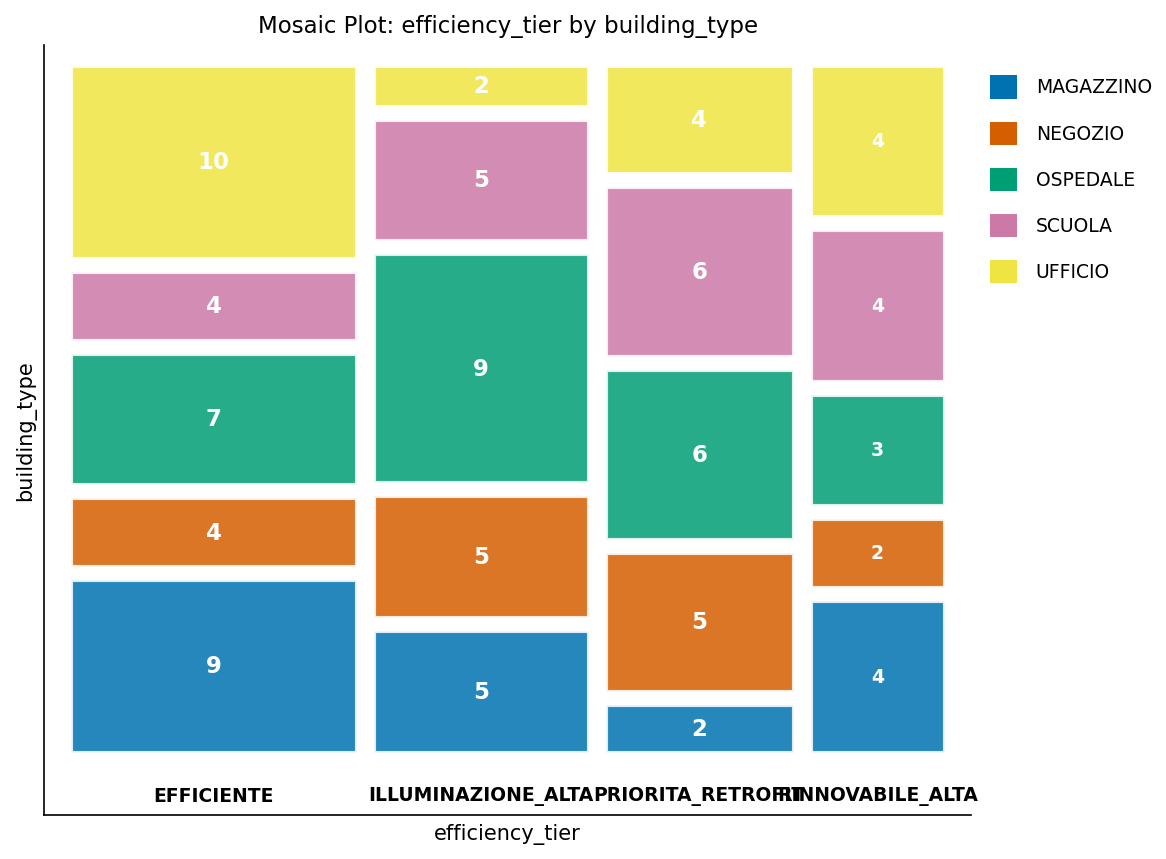

In [10]:
DATI work.bldg_profiled;
    UNIRE work.building_metrics
          work.bldg_clust4 (MANTENERE=building_id cluster distance);
    PER building_id;
ESEGUIRE;

PROCEDURA MEDIE DATI=work.bldg_profiled mean std;
    CLASSE cluster;
    VARIABILE eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    ETICHETTA cluster="Cluster" eui="Intensità di Utilizzo Energetico"
          hvac_efficiency="Efficienza HVAC" envelope_r_value="Resistenza Termica Involucro"
          lighting_wpf="Densità di Potenza Illuminazione" renewable_pct="Percentuale Rinnovabile"
          building_age="Età dell'Edificio";
    TITOLO "Profili dei Livelli di Efficienza degli Edifici (k=4)";
ESEGUIRE;

/* Label efficiency tiers from the observed k=4 centroids:
   Cluster 4 = best HVAC (3.89) at low EUI  -> EFFICIENTE
   Cluster 2 = highest renewable offset (28%) but highest EUI -> RINNOVABILE_ALTA
   Cluster 3 = highest lighting load, weak HVAC, mid EUI -> ILLUMINAZIONE_ALTA
   Cluster 1 = low EUI but weakest HVAC + thinnest envelope -> PRIORITA_RETROFIT */
DATI work.bldg_tiered;
    IMPOSTARE work.bldg_profiled;
    LUNGHEZZA efficiency_tier $24;
    SE_COND cluster = 4 ALLORA efficiency_tier = 'EFFICIENTE';
    ALTRIMENTI SE_COND cluster = 2 ALLORA efficiency_tier = 'RINNOVABILE_ALTA';
    ALTRIMENTI SE_COND cluster = 3 ALLORA efficiency_tier = 'ILLUMINAZIONE_ALTA';
    ALTRIMENTI SE_COND cluster = 1 ALLORA efficiency_tier = 'PRIORITA_RETROFIT';
ESEGUIRE;

PROCEDURA FREQUENZE DATI=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    ETICHETTA efficiency_tier="Livello di Efficienza" building_type="Tipo di Edificio";
    TITOLO "Livello di Efficienza per Tipo di Edificio";
ESEGUIRE;

---

### Interpretazione

Con `REPLACE=FULL`, ogni valore di k converge in modo pulito. Nelle quattro soluzioni, l'R-quadro complessivo cresce in modo monotono con k — 0.305 (k=3), 0.410 (k=4), 0.459 (k=5), 0.515 (k=6) — mentre la statistica pseudo-F raggiunge il picco a **k=4 (22.23)** per poi calare (20.13 a k=5, 19.93 a k=6). Unita a una dimensione minima del cluster di 17 edifici a k=4 (contro 13 a k=5 e 10 a k=6), la **soluzione k=4** offre il miglior equilibrio tra separazione e stabilità dei livelli, quindi viene profilata qui sotto.

I quattro cluster della soluzione k=4 corrispondono a profili di efficienza chiaramente distinti (medie dal profilo PROC MEANS sopra):

- **Efficiente (Cluster 4, n=34):** il gruppo meglio attrezzato — massima efficienza HVAC (COP 3.89) con un EUI basso-moderato di 72.4 kBtu/sqft/anno, involucro adeguato (R 18.8) e compensazione rinnovabile modesta (11.0%).
- **Ad alta quota rinnovabile (Cluster 2, n=17):** i consumatori assoluti più alti (EUI 122.6) ma anche di gran lunga la compensazione rinnovabile più alta (28.2%), con HVAC di fascia media (COP 3.42). Consumo elevato abbinato a generazione in loco.
- **Ad alta illuminazione (Cluster 3, n=26):** EUI medio (94.0) trainato dalla densità di potenza di illuminazione più alta (1.35 W/sqft) e dal secondo HVAC più debole (COP 2.42), nonostante l'involucro più spesso (R 19.6).
- **Priorità di retrofit (Cluster 1, n=23):** EUI basso sulla carta (63.8) ma l'HVAC più debole (COP 2.28) e l'involucro più sottile (R 12.5) — edifici piccoli o poco utilizzati ma scarsamente equipaggiati, i candidati più chiari per retrofit di involucro e HVAC.

La tabulazione incrociata livello-per-tipo-di-edificio mostra che uffici (10) e magazzini (9) dominano il livello efficiente, mentre gli ospedali si concentrano nel livello ad alta illuminazione (9 su 26). Il livello priorità di retrofit è distribuito su tutti i tipi, guidato da ospedali e scuole (6 ciascuno su 23). Per la progettazione dei programmi, i 23 edifici a priorità di retrofit e i 26 ad alta illuminazione sono i target naturali per gli incentivi HVAC e di illuminazione rispettivamente, mentre i 17 edifici ad alta quota rinnovabile — che già generano in loco — sono più adatti a incentivi di riduzione della domanda che a ulteriori incentivi di generazione.

---

In [11]:
PROCEDURA EXPORT DATI=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>